In [1]:
import sys
sys.path.append("..")

In [2]:
from plotting_utils import get_short_name, set_rcParams, get_short_model_name

In [3]:
from omegaconf import OmegaConf
from itertools import combinations
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os
import re

In [4]:
from sentence_transformers import SentenceTransformer, util
from datasets import load_dataset

/Users/c/Library/Caches/pypoetry/virtualenvs/pesto-R9MfnoAy-py3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from presto import Presto

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
set_rcParams()

### Load data and results

In [8]:
paper_figure_path = "../../ICML2024_EmbedEQ/images"

In [9]:
config = OmegaConf.load("../config.yml")

In [10]:
models = {m: SentenceTransformer(*m.split()) for m in config.models}
datasets = {d: load_dataset(*d.split()) for d in config.datasets}

In [11]:
from glob import glob
import scipy.spatial as sp, scipy.cluster.hierarchy as hc

In [140]:
result_files = glob("../component_variation_data/**np-64**hd-2.pkl")
results = dict()
for file in result_files:
    with open(file, "rb") as f:
        dataset = get_short_name(file.split("_d-")[-1].split("_m-")[0])
        model = get_short_model_name(file.split("_m-")[-1].split("_ns-")[0])
        nc = int(file.split("_nc-")[-1].split("_hd")[0])
        results[dataset, model, nc] = pickle.load(f)

In [141]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=0 # this doesn't matter for our purposes here
                    , normalize=config.normalize)
avg_landscapes = dict()
for nc in range(1,5):
    for k,v in results.items():
        if k[-1] == nc:
            avg_landscapes[k] = metric.average_landscape(v["landscapes"])

In [142]:
scores = dict()
for (k1,v1), (k2,v2) in sorted(list(combinations(sorted(avg_landscapes.items()),2)) + [((k,v),(k,v)) for k,v in sorted(avg_landscapes.items())]):
    scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

In [143]:
df = pd.DataFrame(scores).unstack().reset_index(
).rename({0:"score", "level_0":"m1", "level_1":"m2", "level_3":"dim"}, axis=1).groupby(["m1","m2"]
).agg(dict(score=sum)).reset_index().pivot(index="m1", columns="m2", values="score")
df = df.fillna(0) + df.sort_index()[sorted(df.columns)].fillna(0).T

In [144]:
method = "ward"
metric_ = "euclidean"
linkage = hc.linkage(sp.distance.squareform(df), method=method, metric=metric_)

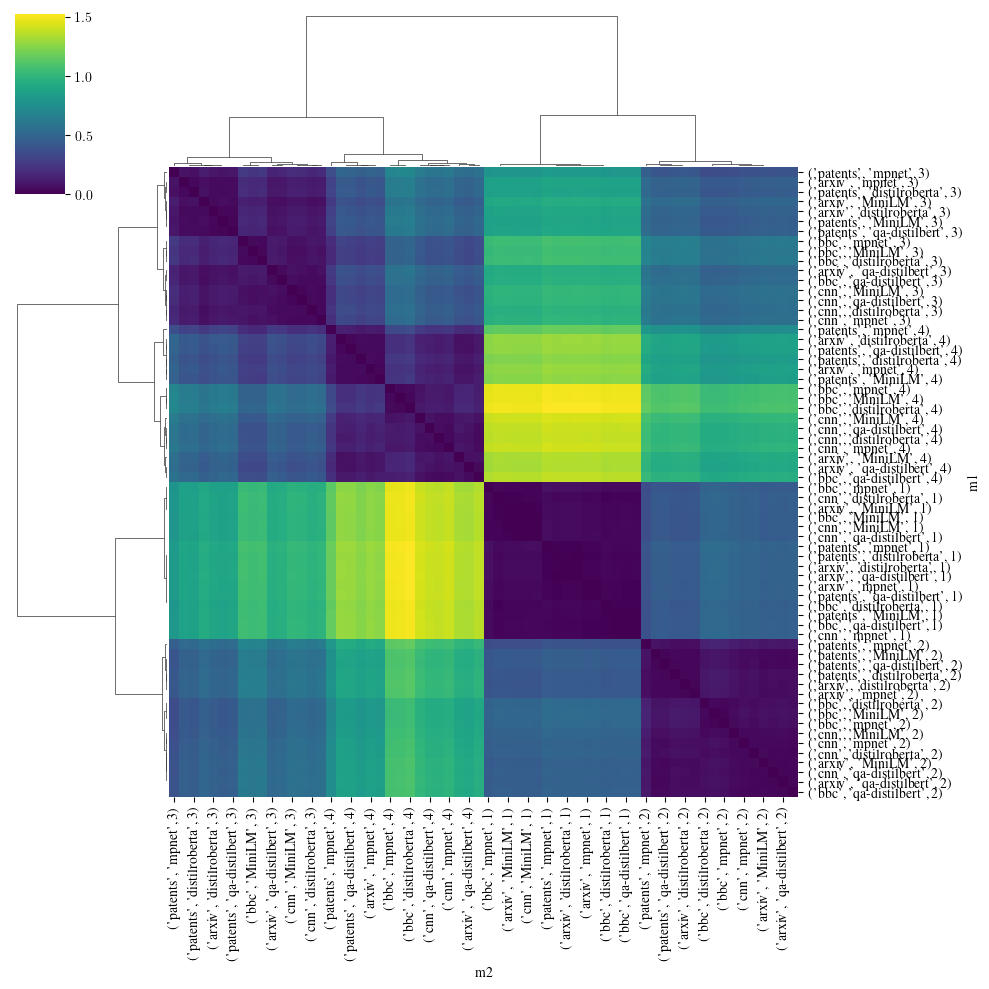

In [145]:
sns.clustermap(df, cmap="viridis", row_linkage=linkage, col_linkage=linkage, yticklabels=1)
plt.savefig(f"{paper_figure_path}/language-model-comparison_clustermap-component-variation.pdf", bbox_inches="tight", transparent=True)

### With subsampling

In [146]:
label_fontsize = 16
legend_fontsize = 12
title_fontsize = 20

In [147]:
sorted_models = ['mpnet','MiniLM', 'distilroberta','qa-distilbert']
sorted_datasets = ['arxiv', 'bbc', 'cnn', 'patents']

In [148]:
metric = Presto(max_homology_dim=config.max_homology_dim, n_components=0 # this doesn't matter for our purposes here
                    , normalize=config.normalize)
rng = np.random.default_rng(42)
subsampled_landscapes = dict()
n_subsamples = 2**5
n_subsample_projections = 2**4
for nc in range(1,5):
    for k,v in results.items():
        if k[-1] == nc:
            for i in range(n_subsample_projections):
                subsampled_landscapes[(*k,i)] = metric.average_landscape({dim:rng.choice(ls, n_subsamples, replace=False) 
                                                                       for dim,ls in v["landscapes"].items()})

In [149]:
subsampled_scores = dict()
for (k1,v1), (k2,v2) in sorted(list(combinations(sorted(subsampled_landscapes.items()),2)) + [((k,v),(k,v)) 
                                                                                              for k,v in sorted(subsampled_landscapes.items())]):
    if k1[0] == k2[0] and k1[2] == k2[2]:
        subsampled_scores[(k1,k2)] = metric.compute_presto_scores(v1, v2)

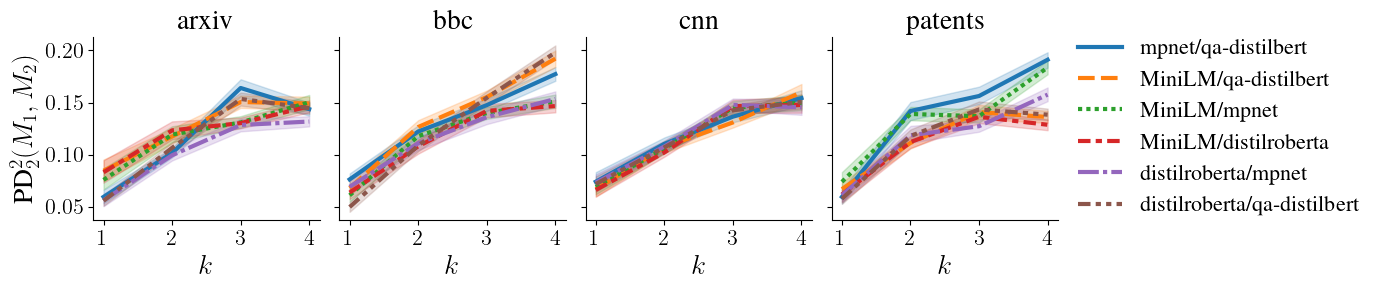

In [150]:
dfl = pd.DataFrame(subsampled_scores).unstack().reset_index(
).rename({0:"score", "level_0":"m1", "level_1":"m2", "level_3":"dim"}, axis=1).groupby(["m1","m2"]
).agg(dict(score=sum)).reset_index()
dfl["m1_nc"] = dfl.m1.map(lambda tup:tup[-2])
dfl["m2_nc"] = dfl.m2.map(lambda tup:tup[-2])
dfl["m1_dataset"] = dfl.m1.map(lambda tup:tup[0])
dfl["m2_dataset"] = dfl.m2.map(lambda tup:tup[0])
dfl["m1_model"] = dfl.m1.map(lambda tup:tup[1])
dfl["m2_model"] = dfl.m2.map(lambda tup:tup[1])
dfl["models"] = dfl["m1_model"]  + "/" + dfl["m2_model"] 
fig, axs = plt.subplots(1,4,figsize=(4*3+2,3), sharex=True, sharey=True)
for ax,dataset in zip(axs,sorted_datasets):
    sns.lineplot(data = dfl.query("m1 != m2 and m1_nc == m2_nc and m1_model != m2_model and m1_dataset == m2_dataset == @dataset"
                                 ).sort_values("m1_model", key=lambda vec:vec.map(lambda x:sorted_models.index(x))), y="score", x="m1_nc", 
                 hue="models", ax=ax, style="models", lw=3, markers=False, #markersize=10, 
                 legend=False if dataset != "patents" else True, seed=rng, errorbar=("ci",99)
                )
    ax.set_xlabel("$k$", fontsize=title_fontsize)
    ax.set_ylabel(r"PD"+"$^2_2(M_1,M_2)$", fontsize=title_fontsize)
    [l.set_fontsize(label_fontsize) for l in ax.get_xticklabels()]
    [l.set_fontsize(label_fontsize) for l in ax.get_yticklabels()]
    ax.set_title(dataset, fontsize=title_fontsize)
axs[-1].legend(bbox_to_anchor=(1,1.1), frameon=False, fontsize=label_fontsize, labelspacing=0.5)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/language-model-comparison_component-variation.pdf", bbox_inches="tight", transparent=True)

### W/o subsampling

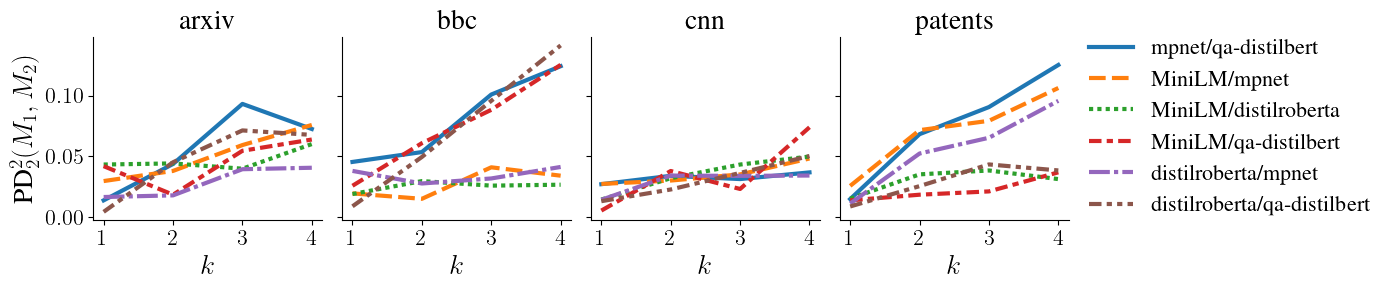

In [151]:
dfl = pd.DataFrame(scores).unstack().reset_index(
).rename({0:"score", "level_0":"m1", "level_1":"m2", "level_3":"dim"}, axis=1).groupby(["m1","m2"]
).agg(dict(score=sum)).reset_index()
dfl["m1_nc"] = dfl.m1.map(lambda tup:tup[-1])
dfl["m2_nc"] = dfl.m2.map(lambda tup:tup[-1])
dfl["m1_dataset"] = dfl.m1.map(lambda tup:tup[0])
dfl["m2_dataset"] = dfl.m2.map(lambda tup:tup[0])
dfl["m1_model"] = dfl.m1.map(lambda tup:tup[1])
dfl["m2_model"] = dfl.m2.map(lambda tup:tup[1])
dfl["models"] = dfl["m1_model"]  + "/" + dfl["m2_model"] 
fig, axs = plt.subplots(1,4,figsize=(4*3+2,3), sharex=True, sharey=True)
for ax,dataset in zip(axs,sorted_datasets):
    sns.lineplot(data = dfl.query("m1 != m2 and m1_nc == m2_nc and m1_model != m2_model and m1_dataset == m2_dataset == @dataset"
                                 ).sort_values("m1_model", key=lambda vec:vec.map(lambda x:sorted_models.index(x))), y="score", x="m1_nc", 
                 hue="models", ax=ax, style="models", lw=3, markers=False, #markersize=10, 
                 legend=False if dataset != "patents" else True, seed=rng
                )
    ax.set_xlabel("$k$", fontsize=title_fontsize)
    ax.set_ylabel(r"PD"+"$^2_2(M_1,M_2)$", fontsize=title_fontsize)
    [l.set_fontsize(label_fontsize) for l in ax.get_xticklabels()]
    [l.set_fontsize(label_fontsize) for l in ax.get_yticklabels()]
    ax.set_title(dataset, fontsize=title_fontsize)
axs[-1].legend(bbox_to_anchor=(1,1.1), frameon=False, fontsize=label_fontsize, labelspacing=0.5)
sns.despine(fig)
plt.tight_layout()
plt.savefig(f"{paper_figure_path}/language-model-comparison_component-variation-nosubsampling.pdf", bbox_inches="tight", transparent=True)